# Propuesta de modelo para el proyecto

__Esta propuesta es meramente informativa, el código asociado y los datos no tienen ninguna relación con el proyecto, meramente sirven como un respaldo de la explicación del mismo__

__Toda la explicación teórica ha sido sacada de https://medium.com/dataness-ai/understanding-temporal-fusion-transformer-9a7a4fcde74b Exceptuando la fórmula del GRN__

__Este código necesita tensorflow y keras y la implementación proporcionada anteriormente es menos sotisficada que la propuesta por google originalmente__

In [1]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

2026-01-24 10:35:11.704585: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-24 10:35:11.714375: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-01-24 10:35:11.725130: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-01-24 10:35:11.728579: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-24 10:35:11.737390: I tensorflow/core/platform/cpu_feature_guar

In [2]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            # Esto hace que TF solo use la memoria que necesita y no toda la VRAM
            tf.config.experimental.set_memory_growth(gpu, True)
        print("✅ Memoria GPU configurada correctamente")
    except RuntimeError as e:
        print(e)

✅ Memoria GPU configurada correctamente


In [3]:
import os
#Corred esta celda si usais un docker de nvdia/tensorflow
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' # Limpia logs innecesarios

## Fundamentos teóricos del modelo

### Modelo propuesto: Temporal Fusion Transformers (TFT)

Los TFT son un modelo de analisis y predicción temporal muy potente, que basa su arquitectura en los Transformers.

De manera resumida hay 4 componentes principales:
1. Los datos pasados 
2. Nuevos datos dependientes del factor temporal, que se dividen en las variables conocidas y un espacio ddesconocido a predecir
3. Variables estáticas no dependientes al paso temporal

Metmáticamente la fórmula es la siguiente:

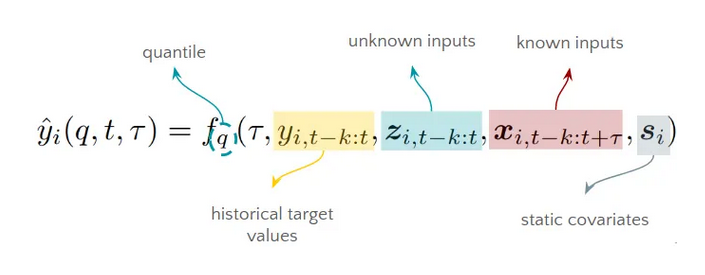

# Arquitectura y Rigurosidad Teórica del Temporal Fusion Transformer (TFT)

El modelo **TFT** está diseñado para manejar la complejidad de las series temporales masivas mediante componentes especializados que gestionan la selección de variables, el procesamiento de secuencias y la predicción de incertidumbre.

---

### 1. Gated Residual Network (GRN)
El **GRN** es la unidad fundamental del TFT. Permite al modelo decidir si una entrada requiere una transformación no lineal compleja o si debe pasar casi intacta para evitar el sobreajuste.

La salida de un bloque $GRN_{\omega}$ para un input $a$ y un contexto opcional $c$ es:
$$GRN_{\omega}(a, c) = \text{LayerNorm}(a + \text{GLU}_{\omega}(\eta_1))$$

**Componentes internos:**
* **Ecuaciones de estado:**
  $$\eta_1 = W_{1,\omega}\eta_2 + b_{1,\omega}$$
  $$\eta_2 = \text{ELU}(W_{2,\omega}a + W_{3,\omega}c + b_{2,\omega})$$
* **ELU (Exponential Linear Unit):** Proporciona gradientes estables permitiendo valores negativos.
* **GLU (Gated Linear Unit):** Actúa como un filtro de información:
  $$\text{GLU}_{\omega}(\gamma) = \sigma(W_{4,\omega}\gamma + b_{4,\omega}) \odot (W_{5,\omega}\gamma + b_{5,\omega})$$
  *(Donde $\odot$ representa el producto de Hadamard o producto elemento a elemento).*



---

### 2. Variable Selection Networks (VSN)
El **VSN** identifica qué variables son ruidosas y cuáles son críticas en cada paso de tiempo. Para un conjunto de variables de entrada $\xi_t^{(1)}, \dots, \xi_t^{(m)}$, se calcula un vector de pesos $v_t$:

$$v_t = \text{Softmax}(\text{GRN}_{v}(\Xi_t))$$

Donde:
* $\Xi_t$ es el vector concatenado de todas las variables de entrada.
* Cada variable sufre una transformación individual: $\tilde{\xi}_t^{(j)} = \text{GRN}_{\xi,j}(\xi_t^{(j)})$.
* La salida final es una combinación lineal ponderada:
  $$\tilde{\xi}_t = \sum_{j=1}^{m} v_t^{(j)} \tilde{\xi}_t^{(j)}$$



---

### 3. Interpretable Multi-Head Attention
A diferencia de los Transformers estándar, el TFT utiliza una estructura de atención que garantiza que la importancia temporal sea explicable.

La atención para un tiempo $t$ se define como:
$$\text{InterpretableMultiHead}(Q, K, V) = \tilde{H}W_O$$

Cada cabezal $h$ se calcula compartiendo la matriz de valores $W_V$:
$$\text{Head}_h = \text{Attention}(QW_{Q,h}, KW_{K,h}, VW_V)$$

Al fijar $W_V$ para todos los cabezales, el modelo puede promediar los pesos de atención para identificar qué momentos del pasado histórico influyeron más en la predicción actual.



---

### 4. Función de Pérdida: Quantile Regression
El TFT predice intervalos de confianza en lugar de valores únicos para cuantificar el riesgo. La pérdida para un cuantil $q$ se calcula como:

$$L(y, \hat{y}_q) = \sum_{i,t} \max(q(y_{i,t} - \hat{y}_{i,t,q}), (1-q)(\hat{y}_{i,t,q} - y_{i,t}))$$

**Interpretación:**
* Si $q=0.5$, la pérdida penaliza por igual las sobreestimaciones y subestimaciones (Mediana).
* Si $q=0.9$, la pérdida penaliza mucho más las subestimaciones, forzando al modelo a predecir un "techo" de demanda.

### Funcionamiento del modelo completo:
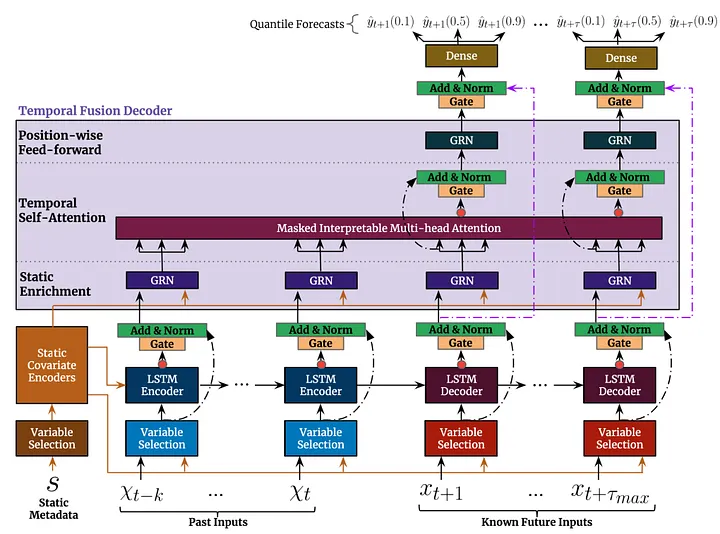

## Implementación de prueba.

Al ser su implementación muy sotisficada, nos basaremos en el repositorio de github de google https://github.com/GoogleCloudPlatform/training-data-analyst, donde está esta arquitecturra junto a muchas otras.


Librerias necesarias

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, Input
import numpy as np
import pandas as pd

Primero implementemos el GRN que es el corazón del modelo

In [ ]:
class GRN(layers.Layer):
    def __init__(self, units, dropout_rate=0.1):
        super(GRN, self).__init__()
        self.units = units
        self.dense_1 = layers.Dense(units)
        self.elu = layers.ELU()
        self.dense_2 = layers.Dense(units)
        self.dropout = layers.Dropout(dropout_rate)
        self.gate = layers.Dense(units, activation='sigmoid')
        self.project = layers.Dense(units) # Para que el residual coincida
        self.layer_norm = layers.LayerNormalization(epsilon=1e-6)

    def call(self, x, training=None):
        # Rama de procesamiento
        h = self.dense_1(x)
        h = self.elu(h)
        h = self.dense_2(h)
        h = self.dropout(h, training=training)
        
        # Gating (GLU)
        gated = self.gate(h) * h 
        
        # Conexión residual
        if x.shape[-1] != self.units:
            x = self.project(x)
            
        return self.layer_norm(x + gated)

Implementemos ahora el metodo de selección de variables

In [ ]:
class VariableSelectionNetwork(layers.Layer):
    def __init__(self, num_features, units, dropout_rate=0.1):
        super(VariableSelectionNetwork, self).__init__()
        self.num_features = num_features
        self.grns = [GRN(units, dropout_rate) for _ in range(num_features)]
        self.selector_grn = GRN(units, dropout_rate)
        self.softmax = layers.Dense(num_features, activation='softmax')

    def call(self, inputs, training=None):
        # inputs es una lista de tensores, uno por cada variable
        transformed = [self.grns[i](inputs[i], training=training) for i in range(self.num_features)]
        
        # Concatenamos para decidir la importancia
        combined = tf.concat(inputs, axis=-1)
        weights = self.selector_grn(combined, training=training)
        weights = self.softmax(weights) # Pesos para cada variable
        weights = tf.expand_dims(weights, axis=-1)
        
        # Suma ponderada de las variables transformadas
        stacked = tf.stack(transformed, axis=-2)
        return tf.reduce_sum(weights * stacked, axis=-2)

Interpretable Multi Head Attention

In [ ]:
class InterpretableMultiHeadAttention(layers.Layer):
    def __init__(self, n_head, d_model):
        super(InterpretableMultiHeadAttention, self).__init__()
        self.n_head = n_head
        self.d_k = d_model // n_head
        self.q_layers = [layers.Dense(self.d_k) for _ in range(n_head)]
        self.k_layers = [layers.Dense(self.d_k) for _ in range(n_head)]
        self.v_layer = layers.Dense(self.d_k) # Wv compartido
        self.out_proj = layers.Dense(d_model) # Wo

    def call(self, q, k, v):
        heads = []
        for i in range(self.n_head):
            qi, ki, vi = self.q_layers[i](q), self.k_layers[i](k), self.v_layer(v)
            score = tf.matmul(qi, ki, transpose_b=True) / tf.math.sqrt(tf.cast(self.d_k, tf.float32))
            attn = tf.nn.softmax(score, axis=-1)
            heads.append(tf.matmul(attn, vi))
        return self.out_proj(tf.concat(heads, axis=-1))

Función de Loss

In [ ]:
def quantile_loss(y_true, y_pred):
    quantiles = [0.1, 0.5, 0.9]
    losses = []
    for i, q in enumerate(quantiles):
        error = y_true - y_pred[:, i:i+1]
        losses.append(tf.reduce_mean(tf.maximum(q * error, (q - 1) * error)))
    return tf.reduce_sum(losses)

In [ ]:
def build_tft(n_past, n_vars, units=64):
    # Entradas: (Pasado, Futuro/Filtros, Estáticos)
    past_inputs = [Input(shape=(n_past, 1), name=f"past_{i}") for i in range(n_vars)]
    future_inputs = [Input(shape=(1, 1), name=f"future_{i}") for i in range(n_vars)]
    static_input = Input(shape=(1,), name="static_zone")

    # Selección de variables
    vsn_past = VariableSelectionNetwork(n_vars, units)(past_inputs)
    vsn_future = VariableSelectionNetwork(n_vars, units)(future_inputs)

    # Procesamiento Temporal (LSTM + Atención)
    lstm_past = layers.LSTM(units, return_sequences=True, unroll=True)(vsn_past)
    lstm_future = layers.LSTM(units, return_sequences=True, unroll=True)(vsn_future)
    attention = InterpretableMultiHeadAttention(n_head=4, d_model=units)(
        q=lstm_future, k=lstm_past, v=lstm_past
    )

    # Capa de salida (3 neuronas para 3 cuantiles)
    x = layers.Flatten()(attention)
    x = GRN(units)(x)
    
    output_demanda = layers.Dense(3, name="demanda")(x) # P10, P50, P90
    output_precio = layers.Dense(3, name="precio")(x)

    model = models.Model(inputs=past_inputs + future_inputs + [static_input], 
                         outputs=[output_demanda, output_precio])
    model.compile(optimizer='adam', loss=quantile_loss)
    return model

Probemos con unos datos arbitrarios. 

El siguiente main ha sido creado con Gemini para facilitar la búsqueda de unos datos limpios para probar el modelo. En caso de que se utilice el modelo este main se verá drasticamente cambiado y adaptado a nuestros datos de demanda de taxis en NY

🚀 Cargando y procesando datos...
🏗️ Construyendo arquitectura TFT de Google...


I0000 00:00:1769250970.657252   34192 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1769250970.661681   34192 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1769250970.666248   34192 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1769250970.771324   34192 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


🧠 Entrenando modelo multivariante...
Epoch 1/15


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

 5/89 [>.............................] - ETA: 1s - loss: 2.4306 - demanda_loss: 1.3809 - precio_loss: 1.0497   

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

89/89 [==============================] - 17s 34ms/step - loss: 0.8044 - demanda_loss: 0.4707 - precio_loss: 0.3337 - val_loss: 0.5082 - val_demanda_loss: 0.3200 - val_precio_loss: 0.1881
Epoch 2/15
89/89 [==============================] - 1s 14ms/step - loss: 0.5860 - demanda_loss: 0.3634 - precio_loss: 0.2226 - val_loss: 0.5660 - val_demanda_loss: 0.3580 - val_precio_loss: 0.2080
Epoch 3/15
89/89 [==============================] - 1s 14ms/step - loss: 0.5201 - demanda_loss: 0.3172 - precio_loss: 0.2030 - val_loss: 0.4557 - val_demanda_loss: 0.2720 - val_precio_loss: 0.1837
Epoch 4/15
89/89 [==============================] - 1s 14ms/step - loss: 0.4942 - demanda_loss: 0.2999 - precio_loss: 0.1943 - val_loss: 0.3879 - val_demanda_loss: 0.2085 - val_precio_loss: 0.1794
Epoch 5/15
89/89 [==============================] - 1s 14ms/step - loss: 0.4457 - demanda_loss: 0.2630 - precio_loss: 0.1828 - val_loss: 0.3910 - val_demanda_loss: 0.2006 - val_precio_loss: 0.1905
Epoch 6/15
89/89 [=======

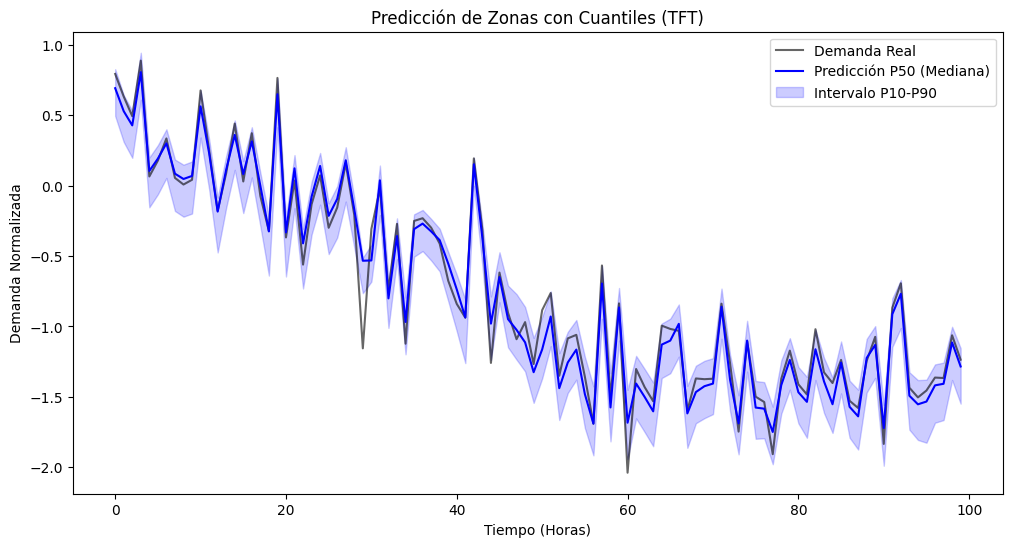

In [ ]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# --- 1. FUNCIÓN PARA PREPARAR DATOS "CÓMODOS" ---
def get_clean_data(n_samples=2000):
    # Simulamos datos de taxis: Demanda influenciada por Clima y Hora
    time = np.linspace(0, 100, n_samples)
    clima = np.sin(time * 0.5) + np.random.normal(0, 0.1, n_samples)
    precio_hist = 15 + 5 * np.cos(time * 0.2) + np.random.normal(0, 0.5, n_samples)
    
    # La demanda depende de ambos
    demanda = 20 + (clima * 10) + (precio_hist * 0.5) + np.random.normal(0, 2, n_samples)
    
    df = pd.DataFrame({'demanda': demanda, 'precio': precio_hist, 'clima': clima})
        # Antes de crear las ventanas:
    df = df.fillna(0) # O usa la media
    scaler = StandardScaler()
    return scaler.fit_transform(df), scaler

# --- 2. GENERADOR DE VENTANAS (WINDOWS) ---
def prepare_windows(data, n_past=24):
    X_past, X_future, y_demanda, y_precio = [], [], [], []
    for i in range(n_past, len(data) - 1):
        # Pasado: las 24 horas anteriores de las 3 variables
        X_past.append(data[i-n_past:i, :])
        # Futuro Conocido: El clima de la hora que queremos predecir (Filtro)
        X_future.append(data[i:i+1, :]) 
        # Objetivos: demanda y precio de la hora actual
        y_demanda.append(data[i, 0])
        y_precio.append(data[i, 1])
        
    return (np.array(X_past), np.array(X_future), 
            np.array(y_demanda), np.array(y_precio))

# --- 3. EL BLOQUE MAIN ---
if __name__ == "__main__":
    # Parámetros
    N_PAST = 24
    N_VARS = 3
    
    print("🚀 Cargando y procesando datos...")
    data_scaled, scaler = get_clean_data()
    X_p, X_f, y_d, y_p = prepare_windows(data_scaled, N_PAST)
    
    # Split Entrenamiento/Prueba (80/20)
    split = int(len(X_p) * 0.8)
    
    # Preparar inputs para el modelo (lista de tensores como pide el TFT)
    def format_inputs(xp, xf):
        # Separamos las 3 variables en listas independientes
        past_list = [xp[:, :, i:i+1] for i in range(N_VARS)]
        future_list = [xf[:, :, i:i+1] for i in range(N_VARS)]
        static_zone = np.zeros((len(xp), 1)) # Zona fija para este test
        return past_list + future_list + [static_zone]

    train_inputs = format_inputs(X_p[:split], X_f[:split])
    test_inputs = format_inputs(X_p[split:], X_f[split:])
    
    print("🏗️ Construyendo arquitectura TFT de Google...")
    tft = build_tft(n_past=N_PAST, n_vars=N_VARS)
    
    print("🧠 Entrenando modelo multivariante...")
    history = tft.fit(
        train_inputs, 
        {'demanda': y_d[:split], 'precio': y_p[:split]},
        epochs=15, 
        batch_size=16,
        validation_split=0.1,
        verbose=1
    )

    print("📊 Evaluando en conjunto de datos externo...")
    preds = tft.predict(test_inputs)
    # preds[0] son los cuantiles de demanda: [P10, P50, P90]
    
    # --- 4. VISUALIZACIÓN DE RESULTADOS ---
    plt.figure(figsize=(12, 6))
    plt.plot(y_d[split:split+100], label="Demanda Real", color='black', alpha=0.6)
    plt.plot(preds[0][:100, 1], label="Predicción P50 (Mediana)", color='blue')
    plt.fill_between(
        range(100), 
        preds[0][:100, 0], preds[0][:100, 2], 
        color='blue', alpha=0.2, label="Intervalo P10-P90"
    )
    plt.title("Predicción de Zonas con Cuantiles (TFT)")
    plt.xlabel("Tiempo (Horas)")
    plt.ylabel("Demanda Normalizada")
    plt.legend()
    plt.show()

Ejemplo de uso forzando variables conocidas

In [ ]:
import numpy as np
import pandas as pd

def predict_scenario(tft_model, scaler, data_source, future_filters, n_past=24, zone_id=0):
    """
    tft_model: El modelo que acabamos de entrenar.
    scaler: El objeto StandardScaler/MinMaxScaler usado.
    data_source: El array 'data_scaled' que contiene los datos históricos.
    future_filters: Diccionario con valores reales (no escalados) para el futuro.
    """
    
    # 1. Extraemos las últimas N_PAST horas del dataset para tener una 'ventana'
    # En un caso real, esto vendría de tu base de datos de taxis.
    ventana_reciente = data_source[-n_past:, :] 
    
    # 2. Preparamos los inputs del pasado (Pasado -> Input 0 a N_VARS-1)
    n_vars = ventana_reciente.shape[1]
    past_inputs = [ventana_reciente[:, i:i+1].reshape(1, n_past, 1) for i in range(n_vars)]
    
    # 3. Preparamos los inputs del futuro (Filtros -> Inputs N_VARS a 2*N_VARS-1)
    # Empezamos con el último valor conocido
    future_raw = ventana_reciente[-1:, :].copy() 
    
    # Aplicamos los filtros del cliente (ej: precio o clima manual)
    # Nota: El scaler espera un vector completo, así que usamos un dummy
    if 'precio' in future_filters:
        dummy = np.zeros((1, n_vars))
        dummy[0, 1] = future_filters['precio'] # Asumiendo índice 1 = precio
        future_raw[0, 1] = scaler.transform(dummy)[0, 1]
        
    if 'clima' in future_filters:
        dummy = np.zeros((1, n_vars))
        dummy[0, 2] = future_filters['clima'] # Asumiendo índice 2 = clima
        future_raw[0, 2] = scaler.transform(dummy)[0, 2]

    future_inputs = [future_raw[:, i:i+1].reshape(1, 1, 1) for i in range(n_vars)]
    
    # 4. Input Estático (Zona)
    static_input = np.array([[zone_id]])
    
    # 5. EJECUTAR PREDICCIÓN CON EL MODELO 'tft'
    # Unimos todos los tensores en la lista que espera el modelo
    all_inputs = past_inputs + future_inputs + [static_input]
    preds = tft_model.predict(all_inputs, verbose=0)
    
    # 6. Des-escalar resultados de Demanda (preds[0])
    # preds[0] tiene forma (1, 3) -> [P10, P50, P90]
    res_demanda_norm = preds[0][0]
    
    # Reconstrucción para inverse_transform
    dummy_out = np.zeros((3, n_vars))
    dummy_out[:, 0] = res_demanda_norm # Ponemos los 3 cuantiles en la col de demanda
    descaled = scaler.inverse_transform(dummy_out)[:, 0]
    
    return descaled # Retorna [Demanda_P10, Demanda_P50, Demanda_P90]

# --- BLOQUE DE PRUEBA REAL ---

print("\n--- Simulador de Escenarios de Taxis ---")

# Escenario A: Día Soleado y Precio Normal
filtros_sol = {'precio': 15.0, 'clima': 1.0} 
p10, p50, p90 = predict_scenario(tft, scaler, data_scaled, filtros_sol)

# Escenario B: Tormenta y Precio Dinámico (Surge)
filtros_tormenta = {'precio': 28.0, 'clima': -1.5} 
p10_t, p50_t, p90_t = predict_scenario(tft, scaler, data_scaled, filtros_tormenta)

print(f"☀️ SOL: Demanda estimada = {p50:.2f} taxis (Rango seguridad: {p10:.2f} - {p90:.2f})")
print(f"⛈️ TORMENTA: Demanda estimada = {p50_t:.2f} taxis (Rango seguridad: {p10_t:.2f} - {p90_t:.2f})")


--- Simulador de Escenarios de Taxis ---


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


☀️ SOL: Demanda estimada = 26.81 taxis (Rango seguridad: 25.41 - 27.78)
⛈️ TORMENTA: Demanda estimada = 25.66 taxis (Rango seguridad: 24.19 - 26.54)


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
